# Examen Corto 1
## Integrantes
- Sergio Orellana 221122
- Rodrigo Mansilla 22611



## **Task 1 - Análisis**

### **1) Dimensión espacial de salida**

**Respuesta:** 
Opción A (Conv $7\times7$, $S=2$, $P=0$):  
$O=\left\lfloor\frac{256-7+2\cdot0}{2}\right\rfloor+1=\left\lfloor124.5\right\rfloor+1=125$  
Obtengo $W_{out}=H_{out}=125$ y el tensor queda $125\times125\times64$.  

Opción B (3 Conv $3\times3$, $S=1$, $P=1$ + MaxPool $2\times2$, $S=2$):  
Cada convolución conserva dimensión:  
$O=\left\lfloor\frac{256-3+2\cdot1}{1}\right\rfloor+1=256$  
Tras 3 convoluciones sigo con $256\times256$. Luego, el max-pooling produce:  
$O=\left\lfloor\frac{256-2+2\cdot0}{2}\right\rfloor+1=\left\lfloor127\right\rfloor+1=128$  
En consecuencia, termino con $128\times128\times64$.

### **2) Parámetros entrenables y justificación**

**Respuesta:**  
Parámetros (pesos) en conv: $K\cdot K\cdot C_{in}\cdot C_{out}$.  

**Opción A:** 
$7\cdot7\cdot4\cdot64=12544$  

**Opción B (solo convoluciones):**  
Conv1: $3\cdot3\cdot4\cdot64=2304$  
Conv2: $3\cdot3\cdot64\cdot64=36864$  
Conv3: $3\cdot3\cdot64\cdot64=36864$  
Total: $2304+36864+36864=76032$  

Aunque la Opción B usa más pesos, la industria la estandarizó porque apilar $3\times3$ incrementa el campo receptivo efectivo (aprox. $7\times7$ tras 3 capas) y, además, introduce más no-linealidades (ReLU) entre etapas. Por tanto, la red aprende representaciones progresivas (de bordes a patrones) con un diseño modular que suele optimizarse y escalar mejor que una sola convolución grande al inicio.


## Task 2 – Criterio

### **1) Justificación técnica**

**Respuesta:**
En un entorno agrícola real, SIFT/HOG suelen fallar porque dependen de gradientes y puntos clave que cambian con la iluminación (sol/sombra), el ángulo de captura y el desenfoque por movimiento; además, las oclusiones (hojas traslapadas o manchas parciales) rompen la consistencia de los descriptores. En consecuencia, el SVM recibe vectores con alta variabilidad intra-clase y separabilidad pobre entre clases, lo que incrementa falsos positivos y falsos negativos.  

Por el contrario, una red profunda construye mapas de características jerárquicos: primero captura bordes y texturas, luego combina esas respuestas para representar patrones semánticos más estables (por ejemplo, distribución y forma de lesiones). Así pues, aprende invariancias útiles a escala y contexto; por tanto, generaliza mejor cuando la escena cambia, aunque la enfermedad sea la misma.

### **2) Elección estricta**

**Respuesta:**
Elijo VGG-16 porque su diseño por bloques de $3\times3$ es más modular y acumula más no-linealidades (ReLU) a mayor profundidad. Por tanto, su extractor tiende a producir características más abstractas y transferibles, lo cual es útil cuando debo distinguir diferencias sutiles de textura y forma en hojas.


## Task 3 – Implementación


In [4]:
# Descarga del dataset (KaggleHub)
import kagglehub

# Descarga del dataset
path = kagglehub.dataset_download("aryashah2k/mango-leaf-disease-dataset")
print("Path to dataset files:", path)


Path to dataset files: C:\Users\sergi\.cache\kagglehub\datasets\aryashah2k\mango-leaf-disease-dataset\versions\1


In [5]:
# Librerías
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models
from torchvision.models import VGG16_Weights
from sklearn.metrics import confusion_matrix, accuracy_score
import matplotlib.pyplot as plt


In [ ]:
# Semillas
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

# Configuración
dataset_root = path
batch_size = 16
num_epochs = 3
lr = 1e-3
val_split = 0.2


In [7]:
# Dispositivo
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cpu')

In [8]:
# Revisar estructura
print(os.listdir(dataset_root)[:20])


['Anthracnose', 'Bacterial Canker', 'Cutting Weevil', 'Die Back', 'Gall Midge', 'Healthy', 'Powdery Mildew', 'Sooty Mould']


In [9]:
# Transformaciones
train_tf = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_tf = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


In [10]:
# Dataset (ImageFolder)
base_ds = datasets.ImageFolder(root=dataset_root)
class_names = base_ds.classes
num_classes = len(class_names)
num_classes, class_names


(8,
 ['Anthracnose',
  'Bacterial Canker',
  'Cutting Weevil',
  'Die Back',
  'Gall Midge',
  'Healthy',
  'Powdery Mildew',
  'Sooty Mould'])

In [11]:
# Split train/val por índices
n_total = len(base_ds)
indices = list(range(n_total))
random.shuffle(indices)

n_val = int(n_total * val_split)
val_idx = indices[:n_val]
train_idx = indices[n_val:]

train_ds = Subset(datasets.ImageFolder(root=dataset_root, transform=train_tf), train_idx)
val_ds = Subset(datasets.ImageFolder(root=dataset_root, transform=val_tf), val_idx)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

len(train_ds), len(val_ds)


(3200, 800)

In [12]:
# Modelo VGG-16 preentrenado
weights = VGG16_Weights.IMAGENET1K_V1
model = models.vgg16(weights=weights)

# Congelar extractor
for p in model.features.parameters():
    p.requires_grad = False

# Reemplazar clasificador final
in_features = model.classifier[6].in_features
model.classifier[6] = nn.Linear(in_features, num_classes)

model = model.to(device)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to C:\Users\sergi/.cache\torch\hub\checkpoints\vgg16-397923af.pth


100%|██████████| 528M/528M [00:31<00:00, 17.6MB/s] 


In [13]:
# Entrenamiento
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.classifier.parameters(), lr=lr)

def run_epoch(loader, train=True):
    model.train(train)
    total_loss = 0.0
    y_true, y_pred = [], []

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        if train:
            optimizer.zero_grad()

        logits = model(x)
        loss = criterion(logits, y)

        if train:
            loss.backward()
            optimizer.step()

        total_loss += loss.item() * x.size(0)
        preds = torch.argmax(logits, dim=1)

        y_true.extend(y.detach().cpu().numpy().tolist())
        y_pred.extend(preds.detach().cpu().numpy().tolist())

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(y_true, y_pred)
    return avg_loss, acc

history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

for epoch in range(1, num_epochs + 1):
    tr_loss, tr_acc = run_epoch(train_loader, train=True)
    va_loss, va_acc = run_epoch(val_loader, train=False)

    history["train_loss"].append(tr_loss)
    history["train_acc"].append(tr_acc)
    history["val_loss"].append(va_loss)
    history["val_acc"].append(va_acc)

    print(f"Epoch {epoch:02d} | train loss {tr_loss:.4f} acc {tr_acc:.4f} | val loss {va_loss:.4f} acc {va_acc:.4f}")


c:\Users\sergi\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\sergi\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch 01 | train loss 1.3190 acc 0.5763 | val loss 0.1765 acc 0.9337


c:\Users\sergi\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\sergi\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch 02 | train loss 0.7317 acc 0.7847 | val loss 0.1274 acc 0.9513


c:\Users\sergi\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\sergi\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch 03 | train loss 0.6239 acc 0.8300 | val loss 0.1076 acc 0.9650


c:\Users\sergi\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\sergi\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch 04 | train loss 0.6460 acc 0.8263 | val loss 0.1120 acc 0.9613


c:\Users\sergi\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\sergi\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch 05 | train loss 0.5920 acc 0.8462 | val loss 0.0399 acc 0.9850


In [14]:
# Evaluación + matriz de confusión
model.eval()
all_true, all_pred = [], []

with torch.no_grad():
    for x, y in val_loader:
        x = x.to(device)
        logits = model(x)
        preds = torch.argmax(logits, dim=1).cpu().numpy().tolist()
        all_pred.extend(preds)
        all_true.extend(y.numpy().tolist())

acc = accuracy_score(all_true, all_pred)
cm = confusion_matrix(all_true, all_pred)

acc, cm.shape


c:\Users\sergi\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


(0.985, (8, 8))

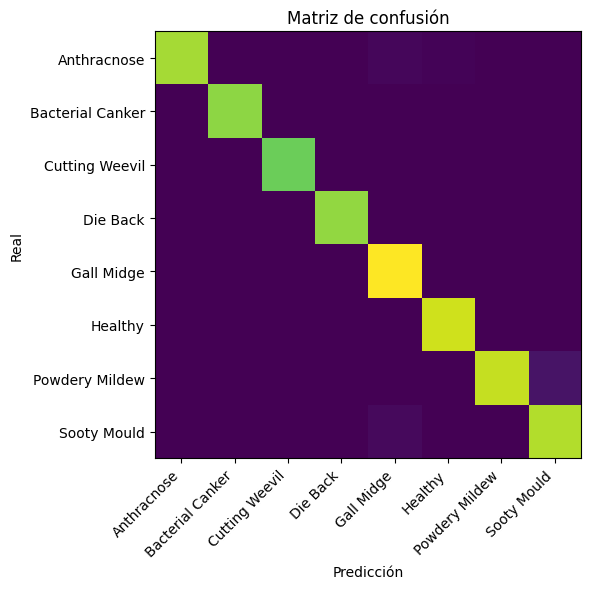

In [15]:
# Visualización matriz de confusión
plt.figure(figsize=(6, 6))
plt.imshow(cm)
plt.title("Matriz de confusión")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.xticks(range(num_classes), class_names, rotation=45, ha="right")
plt.yticks(range(num_classes), class_names)
plt.tight_layout()
plt.show()


## Evaluación y Reporte (Validación/Prueba)

### a) Evaluación en un conjunto no visto
Evalué el modelo usando un conjunto de validación separado del entrenamiento (imágenes que el modelo no vio durante el ajuste). Para ello, generé predicciones sobre `val_loader` y calculé la precisión global con `accuracy_score(all_true, all_pred)`.

### b) **Reporte**

#### i) **Precisión global (Accuracy)**
$Accuracy=0.9850$

#### ii) **Matriz de confusión**
Incluí la matriz de confusión calculada con `confusion_matrix(all_true, all_pred)` y su visualización en el notebook. La figura muestra una matriz mayormente diagonal, lo cual indica que la mayoría de las clases se predicen correctamente; además, los pocos valores fuera de la diagonal representan confusiones puntuales.

#### iii) **Conclusión**
No observo sobreajuste marcado porque la precisión de validación es muy alta y se mantiene estable a lo largo del entrenamiento.  
Además, la validación supera al entrenamiento, lo cual es consistente con el uso de augmentations en train que vuelven ese conjunto más difícil.  
Si en otro escenario viera que train sube mientras val cae, incorporaría Dropout en el clasificador para regularizar y reducir co-adaptaciones.
